<a href="https://colab.research.google.com/github/abhishekCS0024/LangGraph/blob/main/customers_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

In [94]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate

In [95]:
from langchain_groq import ChatGroq
from google.colab import userdata

In [96]:
llm=ChatGroq(
    temperature=0,
    groq_api_key=userdata.get('Groq'),
    model_name="qwen/qwen3-32b",
    verbose=True
)

In [97]:
class State(TypedDict):
  query:str
  category:str
  sentiment:str
  response:str


In [98]:
from pydantic import BaseModel, Field
from typing import Literal

class Category(BaseModel):
  category:Literal["Technical", "Billing", "General"] = Field(description='The category of issue mentioned in the review')

class Tone(BaseModel):
  tone:Literal['Positive', 'Neutral', 'Negative'] = Field(description='The tone of  the  query of the customers')

In [99]:
def category(State):
    """Categorize the customer query into Technical, Billing, or General."""

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a highly efficient customer support triage assistant. "
         "Categorize the customer query into exactly one of: "
         "Technical, Billing, or General."),
        ("human",
         "Here is the customer query: {query}")
    ])

    llm_category = llm.with_structured_output(Category)

    category_obj = llm_category.invoke(
        prompt.format_messages(query=State["query"])
    )
    return {"category": category_obj.category}

In [100]:
def sentiment(State):
  """In order to find the tone of the customers"""
  llm_sentiment=llm.with_structured_output(Tone)

  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "You are a highly efficient customer support triage assistant. listen the user query & analyze the user tone of the query"
          ),
          ("human",
           "Here is the customer query: {query}, Analyze the tone of the query"
          )
      ]
  )

  sentiment_obj = llm_sentiment.invoke(
      prompt.format_messages(query=State["query"])
  )
  return {"sentiment": sentiment_obj.tone}

In [101]:

def Technical(State):
  """Your are the technical support """

  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "You are a Senior Tier-3 Technical Support Engineer specializing in mobile and web applications. Your goal is to provide deep-level troubleshooting for app malfunctions, bugs, and functional failures."),
          ("human",
           "here is the customer query: {query}"),
      ]
  )

  response = llm.invoke(prompt.format_messages(query=State["query"]))
  return {"response": response}

def Billing(State):
  """Your are the technical support """

  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "Your are senior finance officer of the company, your have experience of the accounts & billing"),
          ("human",
           "here is the customer query: {query}"),
      ]
  )

  response = llm.invoke(prompt.format_messages(query=State["query"]))
  return {"response": response}

def General(State):
  """Your are the technical support """

  prompt=ChatPromptTemplate.from_messages(
      [
          ("system",
           "Your are the Customer support agent, that handle the customers genenuine  issue "),
          ("human",
           "here is the customer query: {query}"),
      ]
  )

  response = llm.invoke(prompt.format_messages(query=State["query"]))
  return {"response": response}

def Escalate(state: State) :
    """Escalate the query to a human agent due to negative sentiment."""
    return {"response": "This query has been escalated to a human agent due to its negative sentiment."}

In [102]:
def route_query(State):
  """routing to the specific agent for exact support """
  if State["category"]=="Technical":
    return "Technical"
  elif State["category"]=="Billing":
    return "Billing"
  elif State["sentiment"]=="Negative":
    return "negative"
  else:
    return "General"

In [103]:
workflow=StateGraph(State)

In [104]:
from langgraph.graph import StateGraph, START, END

# Re-initialize the workflow to avoid 'Branch already exists' error on re-execution
# 'State' is assumed to be defined in a previous cell.
workflow = StateGraph(State)

# Add nodes (moved from Rg2vXipyF3qX to ensure they are added after re-initialization)
workflow.add_node("categorize", category)
workflow.add_node("analyze_sentiment", sentiment)
workflow.add_node("handle_technical", Technical)
workflow.add_node("handle_billing", Billing)
workflow.add_node("handle_general", General)
workflow.add_node("escalate", Escalate)

workflow.add_edge(START,"categorize")
workflow.add_edge("categorize","analyze_sentiment")

workflow.add_conditional_edges(
    "analyze_sentiment",
    route_query,
    {
        "Technical": "handle_technical",
        "Billing": "handle_billing",
        "negative": "escalate",
        "General": "handle_general"
    }
)

workflow.add_edge("handle_technical", END)
workflow.add_edge("handle_billing", END)
workflow.add_edge("handle_general", END)
workflow.add_edge("escalate", END)

In [105]:
# Compile the graph

app = workflow.compile()

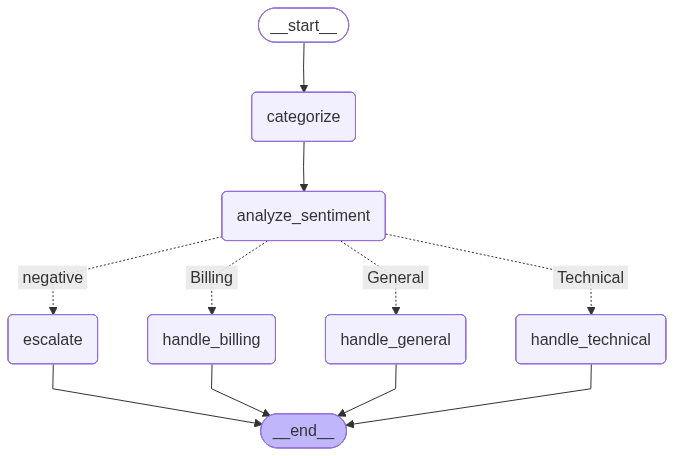

In [106]:
app

In [107]:
intial_state={
    'query': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. This is very frustrating.",
    'category': None,
    'sentiment': None,
    'response': None
}
app.invoke(intial_state)

{'query': "I've been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. This is very frustrating.",
 'category': 'Technical',
 'sentiment': 'Negative',
 'response': AIMessage(content='<think>\nOkay, the user is having trouble logging in because the app freezes on the authentication screen. Let me start by understanding the problem. They\'ve been trying for over an hour, so it\'s been going on for a while. First, I need to consider possible causes. Maybe network issues? If the app can\'t reach the server, it might hang. Or maybe there\'s a problem with the app\'s code, like a bug in the authentication process. Also, device-specific issues could be a factor, such as low memory or outdated OS.\n\nI should ask the user for more details. What device and OS version are they using? The app version is important too. Have they tried restarting the device or the app? Maybe clearing the cache? If they\'re on Wi-Fi, switching to mobile data might help. 

In [108]:
results = app.invoke({"query": "where can i find my receipt?"})

In [109]:
results

{'query': 'where can i find my receipt?',
 'category': 'Billing',
 'sentiment': 'Neutral',
 'response': AIMessage(content='<think>\nOkay, the user is asking where they can find their receipt. Let me start by recalling the common places where receipts are stored. First, they might have received a physical copy, maybe in the mail or at the point of sale. But since the user is asking online, they probably want a digital version.\n\nNext, I should consider the company\'s website. Most companies have a customer portal where users can log in and access their receipts. I should mention checking the account section, perhaps under order history or invoices. If the company uses an app, the app might have a similar feature.\n\nEmail is another common place. The user might have received a confirmation email with a receipt attached. I should suggest checking their inbox, including the spam folder, just in case.\n\nIf the user can\'t find it through the website or email, maybe they need to contact c